# NetMHCstabpan baseline

**London AI x Science Hackathon — Protein Engineering Track**

Explores the dataset and inspects the supervised neural-network baseline reproducing:

> Rasmussen et al. (2016), *"Pan-Specific Prediction of Peptide-MHC Class I Complex Stability,
> a Correlate of T Cell Immunogenicity"*, **J Immunol** 197(4):1517-1524.

### Pipeline

| Stage | Setting |
|---|---|
| Input | 9-mer peptide + 34-residue HLA pseudosequence = 43 positions, BLOSUM50 (normalisation factor 5) -> 860 features |
| Target | $s = 2^{-t_0/t_{1/2}}$, global $t_0 = 1$ h — the paper's fitted optimum (PCC 0.676) |
| Model | one hidden layer, 60 sigmoid units, sigmoid output |
| Split | `--split_strategy`, default `random` |
| Metrics | global & per-allele PCC/SCC, AUC at 1 h and 2 h thresholds |

### Two caveats when comparing to the paper

**The split differs.** The paper used *only* peptide-grouped fivefold cross-validation — unique
peptides partitioned into five sets with every measurement for a peptide kept in one fold, 4/5
train and 1/5 for both test and early stopping. The script does a single holdout and defaults to
`random`, which the paper never used. The closest reproduction is `--split_strategy cluster`.
See `splitting.ipynb` for what that choice costs.

**No ensemble.** The paper averaged networks over two encodings (BLOSUM50 and sparse) and three
hidden-layer widths (40/50/60). The script trains one. Expect the per-allele PCC here to fall
short of the paper's 0.676 for that reason alone.

In [1]:
import os, json
import pandas as pd
import matplotlib.pyplot as plt

# train_baseline.py lives in ../python
import sys; sys.path.append(os.path.abspath('../python'))
from train_baseline import transform_target

# Shared palette (matches splitting.ipynb)
INK, MUTED, GRID = '#1c1c1c', '#6b6b6b', '#dcdcdc'
HUE, ACC = '#2b7a8c', '#b5485d'


def tidy(ax, title, xlabel, ylabel):
    ax.set_title(title, fontsize=11, color=INK, loc='left', pad=10, weight='bold')
    ax.set_xlabel(xlabel, fontsize=9, color=MUTED)
    ax.set_ylabel(ylabel, fontsize=9, color=MUTED)
    ax.grid(axis='y', color=GRID, lw=.6)
    ax.set_axisbelow(True)
    for s in ('top', 'right', 'left'):
        ax.spines[s].set_visible(False)
    ax.spines['bottom'].set_color(GRID)
    ax.tick_params(colors=MUTED, length=0)

### 1. Load the dataset

In [2]:
df = pd.read_csv('../data/rasmussen_et_al_dataset - rasmussen_et_al_dataset.csv')

assert (df['peptide'].str.len() == 9).all(), 'expected all 9-mers'
assert (df['hla_pseudoseq'].str.len() == 34).all(), 'expected all 34-mer pseudosequences'
print(f"{len(df):,} measurements  |  {df['allele'].nunique()} HLA alleles  "
      f"|  {df['peptide'].nunique():,} unique peptides")
df.head()

28,166 measurements  |  75 HLA alleles  |  5,633 unique peptides


,allele,peptide,thalf_hours,hla_seq,hla_pseudoseq
0,HLA-A*02:01,VTTEVAFGL,1.8,GSHSMRYFFTSVSRPGRGEPRFIAVGYVDDTQFVRFDSDAASQRME...,YFAMYGEKVAHTHVDTLYVRYHYYTWAVLAYTWY
1,HLA-A*02:01,FVRQCFNPM,0.1,GSHSMRYFFTSVSRPGRGEPRFIAVGYVDDTQFVRFDSDAASQRME...,YFAMYGEKVAHTHVDTLYVRYHYYTWAVLAYTWY
2,HLA-A*02:01,FVRTLFQQM,0.1,GSHSMRYFFTSVSRPGRGEPRFIAVGYVDDTQFVRFDSDAASQRME...,YFAMYGEKVAHTHVDTLYVRYHYYTWAVLAYTWY
3,HLA-A*02:01,IPKRNRSIL,0.1,GSHSMRYFFTSVSRPGRGEPRFIAVGYVDDTQFVRFDSDAASQRME...,YFAMYGEKVAHTHVDTLYVRYHYYTWAVLAYTWY
4,HLA-A*02:01,QARQMVQAM,0.1,GSHSMRYFFTSVSRPGRGEPRFIAVGYVDDTQFVRFDSDAASQRME...,YFAMYGEKVAHTHVDTLYVRYHYYTWAVLAYTWY


### 2. Target distribution and rescaling

Half-life spans four orders of magnitude, so the left panel uses log-spaced bins on a log axis —
a linear axis collapses everything into one bar. The right panel shows what the rescaling buys:
$s = 2^{-t_0/t_{1/2}}$ maps that onto $[0,1]$. Note the pile-up at both ends — 20% of
measurements are exactly 0 h, and the transform is near-saturated above ~30 h.

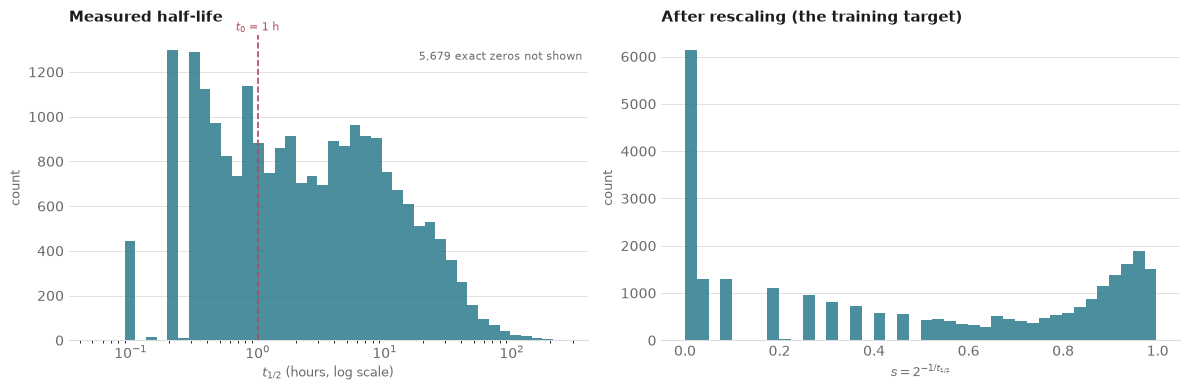

In [3]:
import numpy as np

th = df['thalf_hours'].to_numpy(float)
pos = th[th > 0]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

bins = np.logspace(np.log10(pos.min()), np.log10(pos.max()), 45)
ax1.hist(pos, bins=bins, color=HUE, alpha=.85)
ax1.set_xscale('log')
ax1.axvline(1.0, color=ACC, ls='--', lw=1.2)
ax1.text(1.0, 1.015, '$t_0$ = 1 h', transform=ax1.get_xaxis_transform(),
         fontsize=8, color=ACC, ha='center')
tidy(ax1, 'Measured half-life', '$t_{1/2}$ (hours, log scale)', 'count')
ax1.text(.99, .95, f'{(th == 0).sum():,} exact zeros not shown', transform=ax1.transAxes,
         ha='right', va='top', fontsize=8, color=MUTED)

ax2.hist(transform_target(th, mode='netmhc', t0=1.0), bins=40, color=HUE, alpha=.85)
tidy(ax2, 'After rescaling (the training target)', '$s = 2^{-1/t_{1/2}}$', 'count')

plt.tight_layout(); plt.show()

### 3. Evaluation results

Generated by `python python/train_baseline.py`. The cells below read whatever is currently in
`outputs/` — check the split strategy the run used before reading too much into the numbers, and
regenerate after any change to the model.

In [4]:
metrics_path = '../outputs/metrics.json'
if os.path.exists(metrics_path):
    with open(metrics_path) as f:
        metrics = json.load(f)
    display(pd.Series(metrics, name='value').to_frame())
else:
    print('No metrics yet — run: python python/train_baseline.py')

,value
global_pcc_score,0.715102
global_scc_score,0.723861
global_pcc_thalf,0.439966
global_scc_thalf,0.723861
mean_allele_pcc,0.515816
mean_allele_scc,0.503415
auc_1h,0.868641
auc_2h,0.877499
rmse_hours,10.706905
mae_hours,4.163748


### 4. Per-allele performance

The paper's headline figure is the **mean per-allele PCC** (0.676), not the global PCC, so that is
the row to compare against. Per-allele spread matters too: a high mean can hide alleles the model
has effectively failed on.

73 alleles evaluated  |  mean PCC 0.516  |  paper (peptide-grouped 5-fold CV, ensemble): 0.676


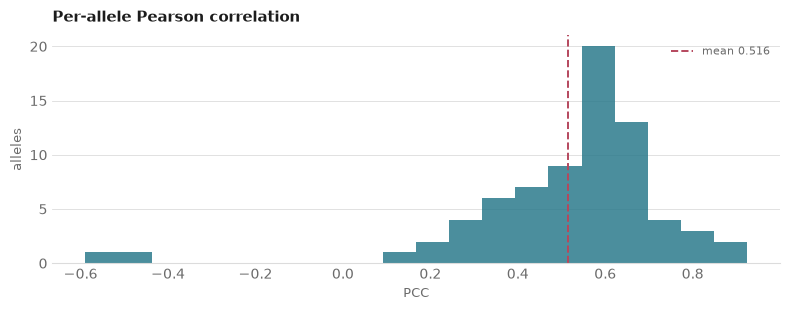

,allele,n_samples,pcc,scc
52,HLA-B*35:08,4,0.924074,0.800000
3,HLA-A*02:05,6,0.860899,0.200000
47,HLA-B*27:03,69,0.842443,0.867655
67,HLA-B*56:01,61,0.835142,0.729569
46,HLA-B*27:02,73,0.784451,0.817331
0,HLA-A*01:01,48,0.206011,0.257057
38,HLA-B*08:03,65,0.193576,0.177682
55,HLA-B*39:06(C67S),74,0.092319,0.166554
33,HLA-A*69:01,4,-0.477841,-0.400000
31,HLA-A*68:02,4,-0.588770,-0.737865


In [5]:
allele_path = '../outputs/allele_metrics.csv'
if os.path.exists(allele_path):
    allele_df = pd.read_csv(allele_path).sort_values('pcc', ascending=False)
    print(f"{len(allele_df)} alleles evaluated  |  mean PCC {allele_df['pcc'].mean():.3f}  "
          f"|  paper (peptide-grouped 5-fold CV, ensemble): 0.676")

    fig, ax = plt.subplots(figsize=(8, 3.2))
    ax.hist(allele_df['pcc'], bins=20, color=HUE, alpha=.85)
    ax.axvline(allele_df['pcc'].mean(), color=ACC, ls='--', lw=1.4,
               label=f"mean {allele_df['pcc'].mean():.3f}")
    ax.legend(frameon=False, fontsize=8, labelcolor=MUTED)
    tidy(ax, 'Per-allele Pearson correlation', 'PCC', 'alleles')
    plt.tight_layout(); plt.show()

    display(pd.concat([allele_df.head(5), allele_df.tail(5)]))
else:
    print('No per-allele metrics yet — run: python python/train_baseline.py')